In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report, cohen_kappa_score,
    precision_recall_fscore_support, matthews_corrcoef, roc_curve, auc
)
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

print('✅ Libraries loaded')

✅ Libraries loaded


## 1. Load Data

In [2]:
# === PATHS - Update these ===
AGENT_FILE = r"C:\Project\Apple Health Data\apple_health_agent\reports\anomaly_agent_output-update.csv"
GNN_FILE   = r"C:\Project\Apple Health Data\apple_health_agent\reports\anomaly_predictions.csv"

# Load
agent_df = pd.read_csv(AGENT_FILE)
gnn_df   = pd.read_csv(GNN_FILE)

print(f"Agent records: {len(agent_df):,}")
print(f"GNN records:   {len(gnn_df):,}")
print(f"\nAgent columns: {list(agent_df.columns)}")
print(f"GNN columns:   {list(gnn_df.columns)}")

Agent records: 360,282
GNN records:   360,178

Agent columns: ['timestamp', 'hr_value', 'predicted_anomaly', 'anomaly_score', 'activity_context', 'hr_zone', 'time_period', 'hour', 'day_of_week', 'is_weekend', 'type']
GNN columns:   ['timestamp', 'hr_value', 'predicted_anomaly', 'anomaly_score', 'activity_context', 'hr_zone', 'time_period', 'hour', 'day_of_week', 'is_weekend', 'type']


In [3]:
# Parse timestamps for merging
agent_df['timestamp'] = pd.to_datetime(agent_df['timestamp'], dayfirst=True, errors='coerce')
gnn_df['timestamp']   = pd.to_datetime(gnn_df['timestamp'], dayfirst=True, errors='coerce')

# Preview
print("=== Agent Sample ===")
display(agent_df.head(3))
print("\n=== GNN Sample ===")
display(gnn_df.head(3))

=== Agent Sample ===


,timestamp,hr_value,predicted_anomaly,anomaly_score,activity_context,hr_zone,time_period,hour,day_of_week,is_weekend,type
0,2017-11-27 09:47:00,82.0,0,0.118373,resting,moderate,morning,9,0,False,HeartRate
1,2017-11-27 10:00:00,72.0,0,0.338289,resting,low,morning,10,0,False,HeartRate
2,2017-11-27 10:01:00,74.0,0,0.247986,resting,low,morning,10,0,False,HeartRate



=== GNN Sample ===


,timestamp,hr_value,predicted_anomaly,anomaly_score,activity_context,hr_zone,time_period,hour,day_of_week,is_weekend,type
0,2017-11-27 09:47:34,82.0,0,0.110758,resting,very_low,morning,9,0,False,HeartRate
1,2017-11-27 10:00:39,72.0,0,0.075281,resting,very_low,morning,10,0,False,HeartRate
2,2017-11-27 10:01:51,74.0,0,0.190959,resting,very_low,morning,10,0,False,HeartRate


## 2. Merge Datasets

In [4]:
# Merge on timestamp (nearest match to handle slight time differences)
# First try exact merge
merged = pd.merge(
    agent_df[['timestamp', 'hr_value', 'predicted_anomaly', 'anomaly_score',
              'activity_context', 'hr_zone', 'time_period', 'hour', 'day_of_week', 'is_weekend']],
    gnn_df[['timestamp', 'predicted_anomaly', 'anomaly_score']],
    on='timestamp',
    how='inner',
    suffixes=('_agent', '_gnn')
)

print(f"Exact timestamp matches: {len(merged):,}")
print(f"Agent unmatched: {len(agent_df) - len(merged):,}")
print(f"GNN unmatched:   {len(gnn_df) - len(merged):,}")

# If exact match is too low, try merge_asof with tolerance
if len(merged) < min(len(agent_df), len(gnn_df)) * 0.5:
    print("\n⚠️ Low exact match rate. Trying fuzzy merge (±1 min tolerance)...")
    agent_sorted = agent_df.sort_values('timestamp')
    gnn_sorted = gnn_df.sort_values('timestamp')
    
    merged = pd.merge_asof(
        agent_sorted[['timestamp', 'hr_value', 'predicted_anomaly', 'anomaly_score',
                       'activity_context', 'hr_zone', 'time_period', 'hour', 'day_of_week', 'is_weekend']],
        gnn_sorted[['timestamp', 'predicted_anomaly', 'anomaly_score']],
        on='timestamp',
        tolerance=pd.Timedelta('1min'),
        direction='nearest',
        suffixes=('_agent', '_gnn')
    ).dropna(subset=['predicted_anomaly_gnn'])
    
    print(f"Fuzzy matched: {len(merged):,}")

print(f"\n✅ Final merged dataset: {len(merged):,} records")

Exact timestamp matches: 12,540
Agent unmatched: 347,742
GNN unmatched:   347,638

⚠️ Low exact match rate. Trying fuzzy merge (±1 min tolerance)...
Fuzzy matched: 360,282

✅ Final merged dataset: 360,282 records


In [5]:
# Ensure integer labels
merged['agent_pred'] = merged['predicted_anomaly_agent'].astype(int)
merged['gnn_pred']   = merged['predicted_anomaly_gnn'].astype(int)

# Quick counts
print("Agent anomaly distribution:")
print(merged['agent_pred'].value_counts().to_string())
print(f"\nGNN anomaly distribution:")
print(merged['gnn_pred'].value_counts().to_string())
print(f"\nAgent anomaly rate: {merged['agent_pred'].mean()*100:.2f}%")
print(f"GNN anomaly rate:   {merged['gnn_pred'].mean()*100:.2f}%")

Agent anomaly distribution:
agent_pred
0    357983
1      2299

GNN anomaly distribution:
gnn_pred
0    357081
1      3201

Agent anomaly rate: 0.64%
GNN anomaly rate:   0.89%


## 3. Confusion Matrix & Agreement

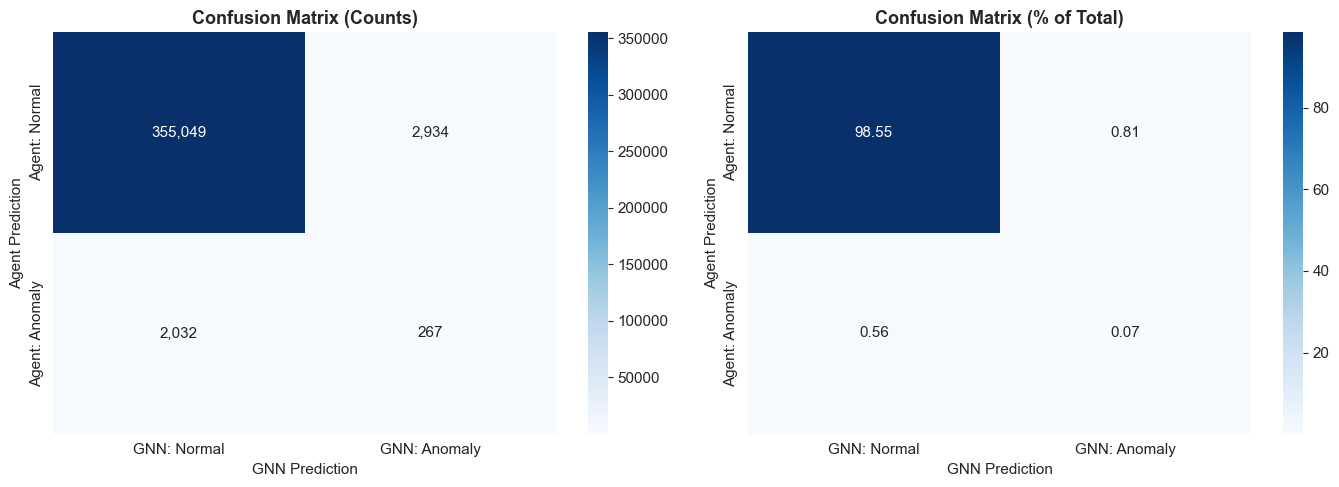


Both agree NORMAL:  355,049 (98.5%)
Both agree ANOMALY: 267 (0.1%)
Agent=Anomaly, GNN=Normal: 2,032 (0.6%) ← Agent-only detections
Agent=Normal, GNN=Anomaly: 2,934 (0.8%) ← GNN-only detections


In [7]:
import os
os.makedirs('reports', exist_ok=True)

# Confusion matrix: rows = Agent, cols = GNN
cm = confusion_matrix(merged['agent_pred'], merged['gnn_pred'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', ax=axes[0],
            xticklabels=['GNN: Normal', 'GNN: Anomaly'],
            yticklabels=['Agent: Normal', 'Agent: Anomaly'])
axes[0].set_title('Confusion Matrix (Counts)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Agent Prediction')
axes[0].set_xlabel('GNN Prediction')

# Normalized (percentages)
cm_pct = cm.astype(float) / cm.sum() * 100
sns.heatmap(cm_pct, annot=True, fmt='.2f', cmap='Blues', ax=axes[1],
            xticklabels=['GNN: Normal', 'GNN: Anomaly'],
            yticklabels=['Agent: Normal', 'Agent: Anomaly'])
axes[1].set_title('Confusion Matrix (% of Total)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Agent Prediction')
axes[1].set_xlabel('GNN Prediction')

plt.tight_layout()
plt.savefig('../results/visualizations/model_comparison/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Interpret
tn, fp, fn, tp = cm.ravel() if cm.size == 4 else (cm[0][0], 0, 0, 0)
print(f"\nBoth agree NORMAL:  {tn:,} ({tn/len(merged)*100:.1f}%)")
print(f"Both agree ANOMALY: {tp:,} ({tp/len(merged)*100:.1f}%)")
print(f"Agent=Anomaly, GNN=Normal: {fn:,} ({fn/len(merged)*100:.1f}%) ← Agent-only detections")
print(f"Agent=Normal, GNN=Anomaly: {fp:,} ({fp/len(merged)*100:.1f}%) ← GNN-only detections")

In [8]:
# Agreement metrics
agreement = (merged['agent_pred'] == merged['gnn_pred']).mean()
kappa = cohen_kappa_score(merged['agent_pred'], merged['gnn_pred'])
mcc = matthews_corrcoef(merged['agent_pred'], merged['gnn_pred'])

print("=" * 50)
print("MODEL AGREEMENT METRICS")
print("=" * 50)
print(f"Overall agreement:       {agreement*100:.2f}%")
print(f"Cohen's Kappa:           {kappa:.4f}")
print(f"Matthews Corr Coeff:     {mcc:.4f}")
print()
print("Kappa interpretation:")
print("  < 0.20 = Poor | 0.21-0.40 = Fair | 0.41-0.60 = Moderate")
print("  0.61-0.80 = Substantial | 0.81-1.00 = Almost Perfect")

MODEL AGREEMENT METRICS
Overall agreement:       98.62%
Cohen's Kappa:           0.0903
Matthews Corr Coeff:     0.0916

Kappa interpretation:
  < 0.20 = Poor | 0.21-0.40 = Fair | 0.41-0.60 = Moderate
  0.61-0.80 = Substantial | 0.81-1.00 = Almost Perfect


## 4. Cross-Classification Report
Using each model as "ground truth" for the other.

In [9]:
print("=" * 60)
print("Agent predictions evaluated against GNN as reference:")
print("=" * 60)
print(classification_report(
    merged['gnn_pred'], merged['agent_pred'],
    target_names=['Normal', 'Anomaly'], zero_division=0
))

print("=" * 60)
print("GNN predictions evaluated against Agent as reference:")
print("=" * 60)
print(classification_report(
    merged['agent_pred'], merged['gnn_pred'],
    target_names=['Normal', 'Anomaly'], zero_division=0
))

Agent predictions evaluated against GNN as reference:
              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99    357081
     Anomaly       0.12      0.08      0.10      3201

    accuracy                           0.99    360282
   macro avg       0.55      0.54      0.55    360282
weighted avg       0.98      0.99      0.99    360282

GNN predictions evaluated against Agent as reference:
              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99    357983
     Anomaly       0.08      0.12      0.10      2299

    accuracy                           0.99    360282
   macro avg       0.54      0.55      0.55    360282
weighted avg       0.99      0.99      0.99    360282



## 5. Anomaly Score Comparison

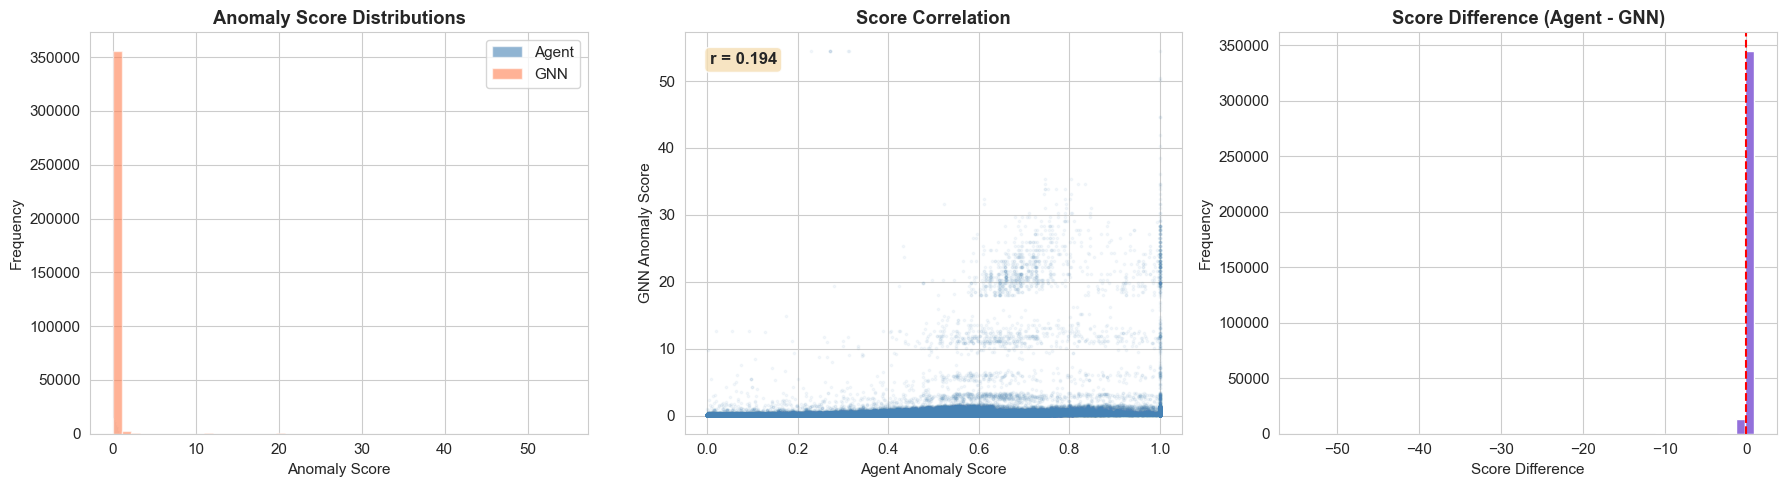

Score correlation (Pearson): 0.1943
Mean Agent score: 0.3033
Mean GNN score:   0.2552


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Score distributions
axes[0].hist(merged['anomaly_score_agent'], bins=50, alpha=0.6, label='Agent', color='steelblue', edgecolor='white')
axes[0].hist(merged['anomaly_score_gnn'], bins=50, alpha=0.6, label='GNN', color='coral', edgecolor='white')
axes[0].set_title('Anomaly Score Distributions', fontweight='bold')
axes[0].set_xlabel('Anomaly Score')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Score scatter
axes[1].scatter(merged['anomaly_score_agent'], merged['anomaly_score_gnn'],
                alpha=0.05, s=3, c='steelblue')
axes[1].set_xlabel('Agent Anomaly Score')
axes[1].set_ylabel('GNN Anomaly Score')
axes[1].set_title('Score Correlation', fontweight='bold')
corr = merged['anomaly_score_agent'].corr(merged['anomaly_score_gnn'])
axes[1].text(0.05, 0.95, f'r = {corr:.3f}', transform=axes[1].transAxes,
             fontsize=12, fontweight='bold', va='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# Score difference distribution
score_diff = merged['anomaly_score_agent'] - merged['anomaly_score_gnn']
axes[2].hist(score_diff, bins=50, color='mediumpurple', edgecolor='white')
axes[2].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[2].set_title('Score Difference (Agent - GNN)', fontweight='bold')
axes[2].set_xlabel('Score Difference')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('../results/visualizations/model_comparison/score_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Score correlation (Pearson): {corr:.4f}")
print(f"Mean Agent score: {merged['anomaly_score_agent'].mean():.4f}")
print(f"Mean GNN score:   {merged['anomaly_score_gnn'].mean():.4f}")

## 6. Disagreement Analysis
Where the two models disagree — what makes these records different?

In [11]:
# Create agreement categories
merged['agreement'] = 'Both Normal'
merged.loc[(merged['agent_pred'] == 1) & (merged['gnn_pred'] == 1), 'agreement'] = 'Both Anomaly'
merged.loc[(merged['agent_pred'] == 1) & (merged['gnn_pred'] == 0), 'agreement'] = 'Agent Only'
merged.loc[(merged['agent_pred'] == 0) & (merged['gnn_pred'] == 1), 'agreement'] = 'GNN Only'

print("Agreement Category Distribution:")
print(merged['agreement'].value_counts().to_string())
print()

# HR statistics by agreement category
print("HR Statistics by Agreement Category:")
print("=" * 70)
summary = merged.groupby('agreement')['hr_value'].agg(['mean', 'std', 'median', 'min', 'max', 'count'])
print(summary.round(1).to_string())

Agreement Category Distribution:
agreement
Both Normal     355049
GNN Only          2934
Agent Only        2032
Both Anomaly       267

HR Statistics by Agreement Category:
               mean   std  median   min    max   count
agreement                                             
Agent Only    109.8  29.4   123.0  42.0  199.0    2032
Both Anomaly   61.3  21.0    57.0  41.0  170.0     267
Both Normal    87.6  11.4    86.0  54.0  184.0  355049
GNN Only       66.6  17.9    60.0  51.0  157.0    2934


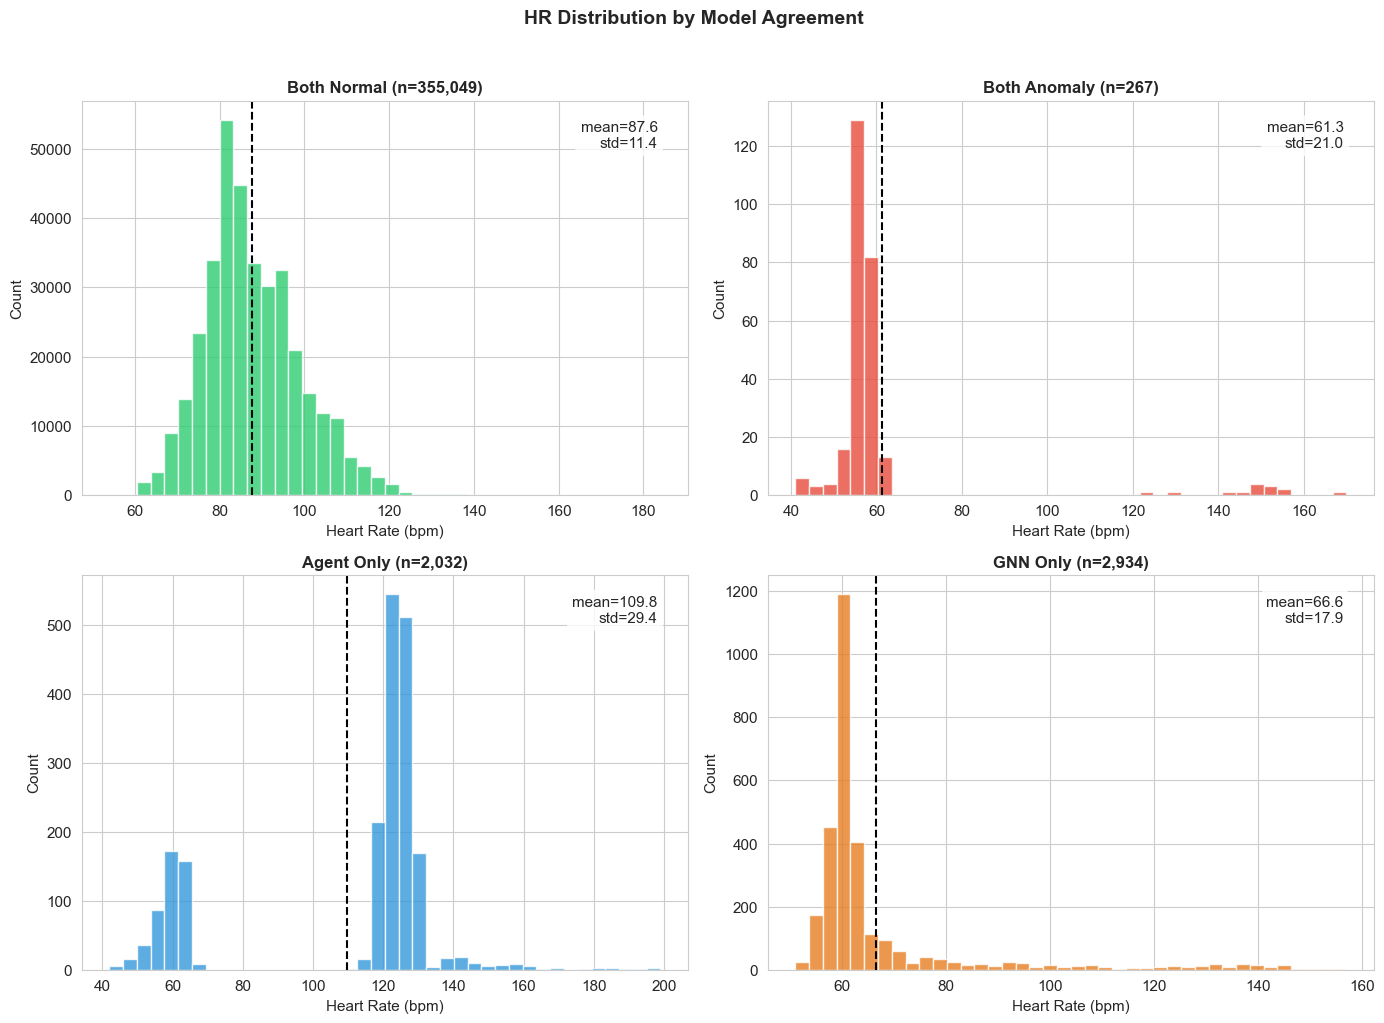

In [12]:
# HR distribution by agreement category
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

categories = ['Both Normal', 'Both Anomaly', 'Agent Only', 'GNN Only']
colors = ['#2ecc71', '#e74c3c', '#3498db', '#e67e22']

for ax, cat, color in zip(axes.flat, categories, colors):
    subset = merged[merged['agreement'] == cat]
    if len(subset) > 0:
        ax.hist(subset['hr_value'], bins=40, color=color, edgecolor='white', alpha=0.8)
        ax.axvline(subset['hr_value'].mean(), color='black', linestyle='--', linewidth=1.5)
        ax.set_title(f'{cat} (n={len(subset):,})', fontweight='bold', fontsize=12)
        ax.set_xlabel('Heart Rate (bpm)')
        ax.set_ylabel('Count')
        ax.text(0.95, 0.95, f"mean={subset['hr_value'].mean():.1f}\nstd={subset['hr_value'].std():.1f}",
                transform=ax.transAxes, va='top', ha='right',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    else:
        ax.text(0.5, 0.5, 'No records', transform=ax.transAxes, ha='center', va='center')
        ax.set_title(f'{cat} (n=0)', fontweight='bold')

plt.suptitle('HR Distribution by Model Agreement', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../results/visualizations/model_comparison/hr_by_agreement.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# Disagreement breakdown by context
print("=" * 70)
print("DISAGREEMENT PATTERNS BY CONTEXT")
print("=" * 70)

for context_col, label in [('activity_context', 'Activity'), 
                            ('time_period', 'Time Period'),
                            ('hr_zone', 'HR Zone')]:
    if context_col in merged.columns:
        ct = pd.crosstab(merged[context_col], merged['agreement'], normalize='index') * 100
        print(f"\n--- By {label} (% within each category) ---")
        print(ct.round(1).to_string())

DISAGREEMENT PATTERNS BY CONTEXT

--- By Activity (% within each category) ---
agreement         Agent Only  Both Anomaly  Both Normal  GNN Only
activity_context                                                 
active                   3.0           0.0         96.8       0.2
exercise                10.0           1.3         77.6      11.1
intense                 72.0           4.0         24.0       0.0
resting                  0.2           0.1         98.9       0.9

--- By Time Period (% within each category) ---
agreement    Agent Only  Both Anomaly  Both Normal  GNN Only
time_period                                                 
afternoon           0.7           0.1         99.1       0.2
evening             0.6           0.0         99.2       0.2
late_night          0.4           0.1         99.2       0.3
morning             0.5           0.1         98.7       0.7
night               0.3           0.0         91.1       8.6

--- By HR Zone (% within each category) ---
agre

## 7. Temporal Analysis
When do the models agree and disagree over time?

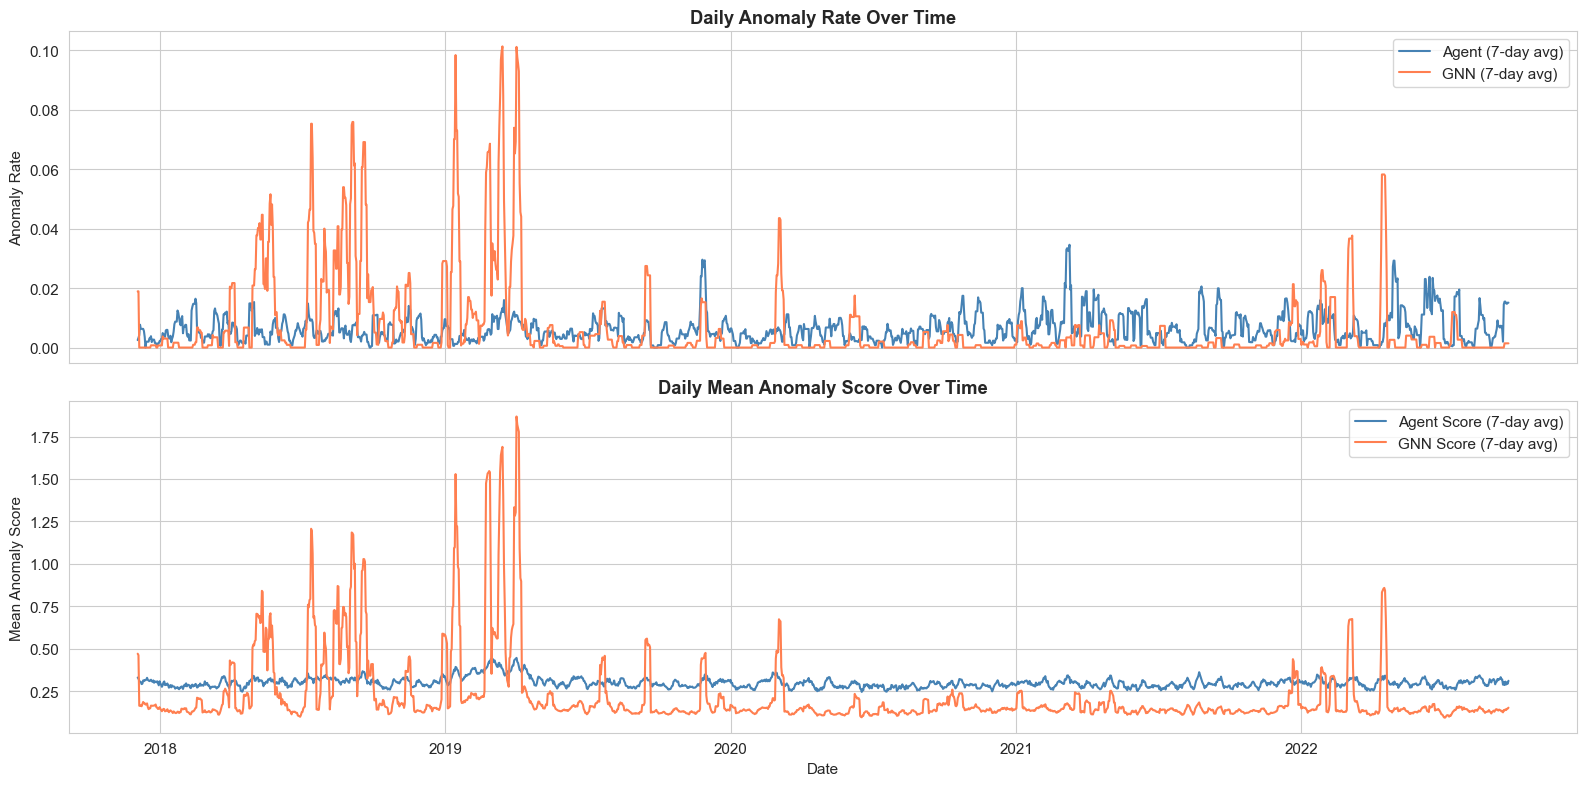

In [14]:
# Daily anomaly rates for both models
merged['date'] = merged['timestamp'].dt.date
daily = merged.groupby('date').agg(
    agent_anomaly_rate=('agent_pred', 'mean'),
    gnn_anomaly_rate=('gnn_pred', 'mean'),
    agent_score_mean=('anomaly_score_agent', 'mean'),
    gnn_score_mean=('anomaly_score_gnn', 'mean'),
    record_count=('hr_value', 'count')
).reset_index()

daily['date'] = pd.to_datetime(daily['date'])

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

# Daily anomaly rates
axes[0].plot(daily['date'], daily['agent_anomaly_rate'].rolling(7).mean(),
             label='Agent (7-day avg)', color='steelblue', linewidth=1.5)
axes[0].plot(daily['date'], daily['gnn_anomaly_rate'].rolling(7).mean(),
             label='GNN (7-day avg)', color='coral', linewidth=1.5)
axes[0].set_ylabel('Anomaly Rate')
axes[0].set_title('Daily Anomaly Rate Over Time', fontweight='bold')
axes[0].legend()

# Daily score means
axes[1].plot(daily['date'], daily['agent_score_mean'].rolling(7).mean(),
             label='Agent Score (7-day avg)', color='steelblue', linewidth=1.5)
axes[1].plot(daily['date'], daily['gnn_score_mean'].rolling(7).mean(),
             label='GNN Score (7-day avg)', color='coral', linewidth=1.5)
axes[1].set_ylabel('Mean Anomaly Score')
axes[1].set_xlabel('Date')
axes[1].set_title('Daily Mean Anomaly Score Over Time', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('../results/visualizations/model_comparison/temporal_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. ROC-style Analysis
Using each model as proxy ground truth for the other's scores.

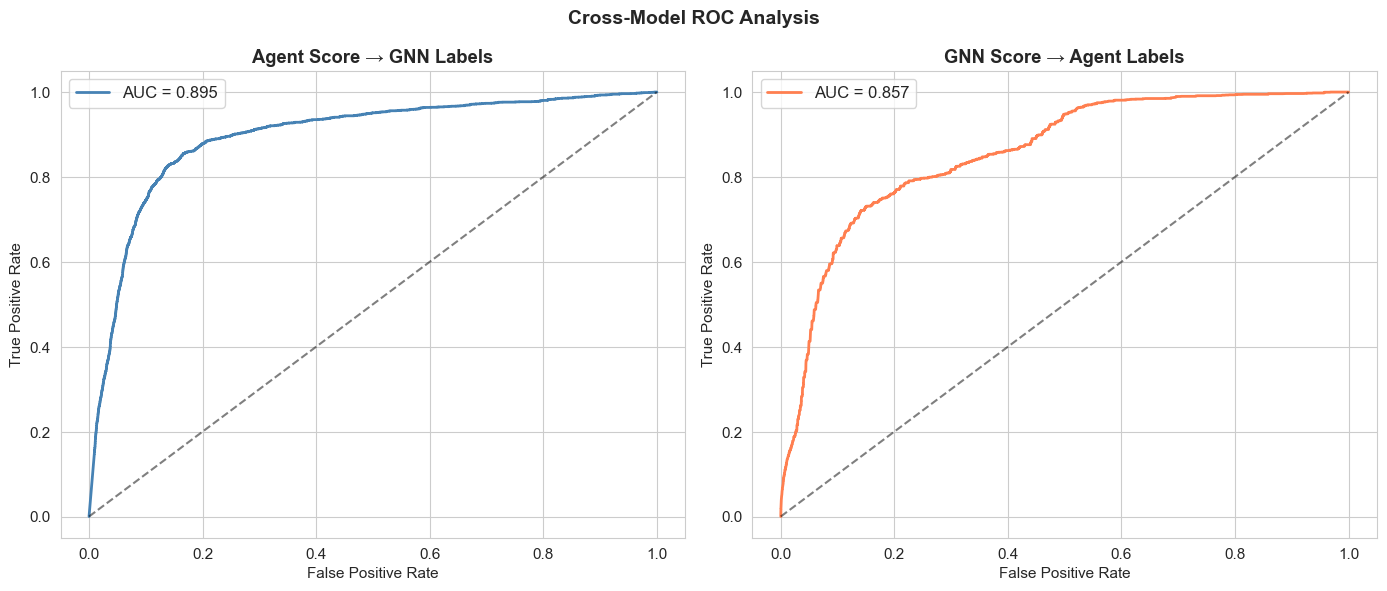

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Agent score predicting GNN labels
if merged['gnn_pred'].nunique() > 1:
    fpr, tpr, _ = roc_curve(merged['gnn_pred'], merged['anomaly_score_agent'])
    roc_auc = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, color='steelblue', linewidth=2, label=f'AUC = {roc_auc:.3f}')
    axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
    axes[0].set_title('Agent Score → GNN Labels', fontweight='bold')
    axes[0].set_xlabel('False Positive Rate')
    axes[0].set_ylabel('True Positive Rate')
    axes[0].legend(fontsize=12)

# GNN score predicting Agent labels
if merged['agent_pred'].nunique() > 1:
    fpr, tpr, _ = roc_curve(merged['agent_pred'], merged['anomaly_score_gnn'])
    roc_auc = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, color='coral', linewidth=2, label=f'AUC = {roc_auc:.3f}')
    axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
    axes[1].set_title('GNN Score → Agent Labels', fontweight='bold')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].legend(fontsize=12)

plt.suptitle('Cross-Model ROC Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/visualizations/model_comparison/roc_cross_model.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Ensemble Analysis
What if we combine both models?

In [16]:
# Ensemble strategies
merged['ensemble_or']  = ((merged['agent_pred'] == 1) | (merged['gnn_pred'] == 1)).astype(int)   # Either flags
merged['ensemble_and'] = ((merged['agent_pred'] == 1) & (merged['gnn_pred'] == 1)).astype(int)   # Both agree
merged['ensemble_avg_score'] = (merged['anomaly_score_agent'] + merged['anomaly_score_gnn']) / 2  # Score average
merged['ensemble_score_flag'] = (merged['ensemble_avg_score'] > 0.5).astype(int)                  # Score threshold

print("Ensemble Strategy Comparison:")
print("=" * 60)
strategies = {
    'Agent alone':     merged['agent_pred'].sum(),
    'GNN alone':       merged['gnn_pred'].sum(),
    'OR (either)':     merged['ensemble_or'].sum(),
    'AND (both)':      merged['ensemble_and'].sum(),
    'Avg score > 0.5': merged['ensemble_score_flag'].sum(),
}

for name, count in strategies.items():
    print(f"  {name:20s}: {count:>8,} anomalies ({count/len(merged)*100:.2f}%)")

Ensemble Strategy Comparison:
  Agent alone         :    2,299 anomalies (0.64%)
  GNN alone           :    3,201 anomalies (0.89%)
  OR (either)         :    5,233 anomalies (1.45%)
  AND (both)          :      267 anomalies (0.07%)
  Avg score > 0.5     :   24,048 anomalies (6.67%)


## 10. Summary & Export

In [17]:
# Final summary
print("\n" + "=" * 70)
print("📊 MODEL COMPARISON SUMMARY")
print("=" * 70)
print(f"\nDataset: {len(merged):,} matched records")
print(f"\nAnomaly Detection Rates:")
print(f"  Agent: {merged['agent_pred'].mean()*100:.2f}% ({merged['agent_pred'].sum():,} records)")
print(f"  GNN:   {merged['gnn_pred'].mean()*100:.2f}% ({merged['gnn_pred'].sum():,} records)")
print(f"\nAgreement Metrics:")
print(f"  Overall agreement: {agreement*100:.2f}%")
print(f"  Cohen's Kappa:     {kappa:.4f}")
print(f"  Matthews Corr:     {mcc:.4f}")
print(f"  Score correlation: {corr:.4f}")
print(f"\nDisagreement Breakdown:")
print(f"  Both Normal:  {(merged['agreement'] == 'Both Normal').sum():,}")
print(f"  Both Anomaly: {(merged['agreement'] == 'Both Anomaly').sum():,}")
print(f"  Agent Only:   {(merged['agreement'] == 'Agent Only').sum():,}")
print(f"  GNN Only:     {(merged['agreement'] == 'GNN Only').sum():,}")
print("=" * 70)


📊 MODEL COMPARISON SUMMARY

Dataset: 360,282 matched records

Anomaly Detection Rates:
  Agent: 0.64% (2,299 records)
  GNN:   0.89% (3,201 records)

Agreement Metrics:
  Overall agreement: 98.62%
  Cohen's Kappa:     0.0903
  Matthews Corr:     0.0916
  Score correlation: 0.1943

Disagreement Breakdown:
  Both Normal:  355,049
  Both Anomaly: 267
  Agent Only:   2,032
  GNN Only:     2,934


In [18]:
# Export merged comparison dataset
export_path = '../results/data/model_comparison_full.csv'
merged.to_csv(export_path, index=False)
print(f"✅ Full comparison exported → {export_path}")

# Export disagreements only (for manual review)
disagreements = merged[merged['agreement'].isin(['Agent Only', 'GNN Only'])]
disagree_path = '../results/data/model_disagreements.csv'
disagreements.to_csv(disagree_path, index=False)
print(f"✅ Disagreements exported → {disagree_path} ({len(disagreements):,} records)")

✅ Full comparison exported → ../results/data/model_comparison_full.csv
✅ Disagreements exported → ../results/data/model_disagreements.csv (4,966 records)
